In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
from scipy import stats

# BTC Stylised Facts
- Get BTCUSD Prices
- Evidence of no autocorrelation
- Evidence of significant persistence
- Evidence of heavy tails

## Download BTCUSD Prices

In [3]:
# Download Data
px = yf.download('BTC-USD', start="2016-01-01", end="2026-01-01", auto_adjust=False, interval='1d')['Adj Close']
ret = (np.log(px) - np.log(px.shift())).dropna()
ret.columns = ['BTC-USD']
pd.to_pickle(px, 'data/px.pk')
pd.to_pickle(ret, 'data/ret.pk')

C:\Users\frase\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


## Autocorrelation Testing

$$
\hat\rho(\tau) = \text{corr}(X_t,X_{t - \tau}) \\
\hat\rho_2(\tau) = \text{corr}(|X_t|,|X_{t - \tau}|)
$$

(-0.1, 0.1)

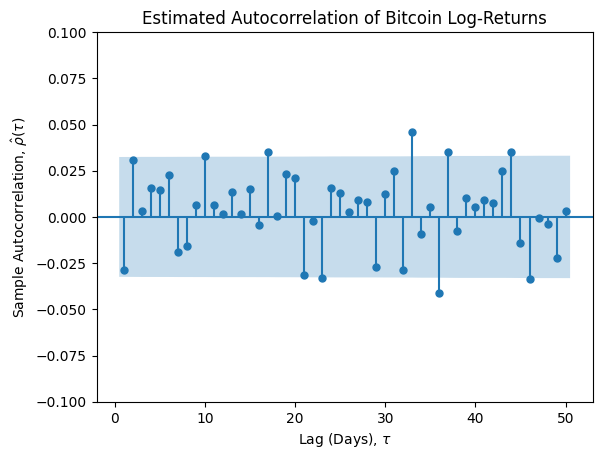

In [12]:
# ACF Graph BTC
sm.graphics.tsa.plot_acf(ret.dropna(), lags=50, zero=False, title='Estimated Autocorrelation of Bitcoin Log-Returns')
plt.ylabel(r'Sample Autocorrelation, $\hat{\rho}(\tau)$')
plt.xlabel(r'Lag (Days), $\tau$')
plt.ylim([-0.1, 0.1])

(-0.1, 0.3)

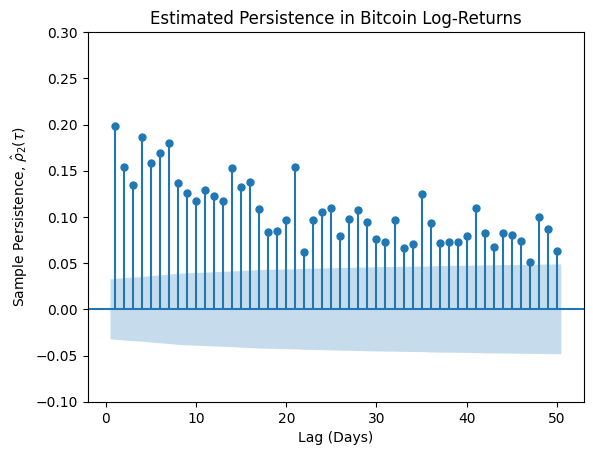

In [18]:
# Persistence Graph BTC
sm.graphics.tsa.plot_acf((np.abs(ret.dropna())), lags=50, zero=False, title='Estimated Persistence in Bitcoin Log-Returns')
plt.ylabel(r'Sample Persistence, $\hat{\rho}_2(\tau)$')
plt.xlabel('Lag (Days)')
plt.ylim([-0.1, 0.3])

## Heavy Tails

Text(0.5, 1.0, 'Normal QQ-Plot for Simulated GARCH Values')

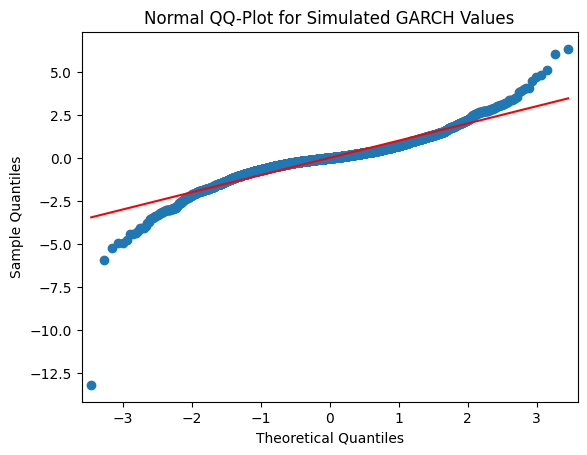

In [27]:
# QQ-Plot BTC
sm.qqplot(ret['BTC-USD'].sort_values(), stats.norm, fit=True, line='s')
plt.title('Normal QQ-Plot for Simulated GARCH Values')